In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")
 
master = pd.read_csv("../data/processed/master_df.csv", parse_dates=["ds"])
train  = pd.read_csv("../data/processed/master_df.csv",  parse_dates=["ds"])
 
FEATURE_COLS = [
    "production_dev_pct",
    "price_mom_3m",
    "price_accel",
    "harvest_window",
    "rainfall_dev_pct",
]
 
print(f"master_df loaded: {master.shape}")
print(f"train_df loaded:  {train.shape}")
print(f"\nColumn dtypes:")
print(master.dtypes)
print(f"\nBasic stats:")
print(master[["y"] + FEATURE_COLS].describe().round(3))

master_df loaded: (77, 9)
train_df loaded:  (77, 9)

Column dtypes:
ds                        datetime64[ns]
y                                float64
price_mom_3m                     float64
price_accel                      float64
production_dev_pct               float64
rainfall_dev_pct                 float64
harvest_window                     int64
lean_season                        int64
harvest_proximity_days             int64
dtype: object

Basic stats:
               y  production_dev_pct  price_mom_3m  price_accel  \
count     77.000              77.000        77.000       77.000   
mean   12049.622               0.045         0.015       -0.010   
std     1686.977               0.258         0.039        0.030   
min     9984.917              -0.409        -0.103       -0.104   
25%    10560.471              -0.022        -0.013       -0.021   
50%    11388.778              -0.003         0.007       -0.003   
75%    13788.889               0.014         0.033        0.007   

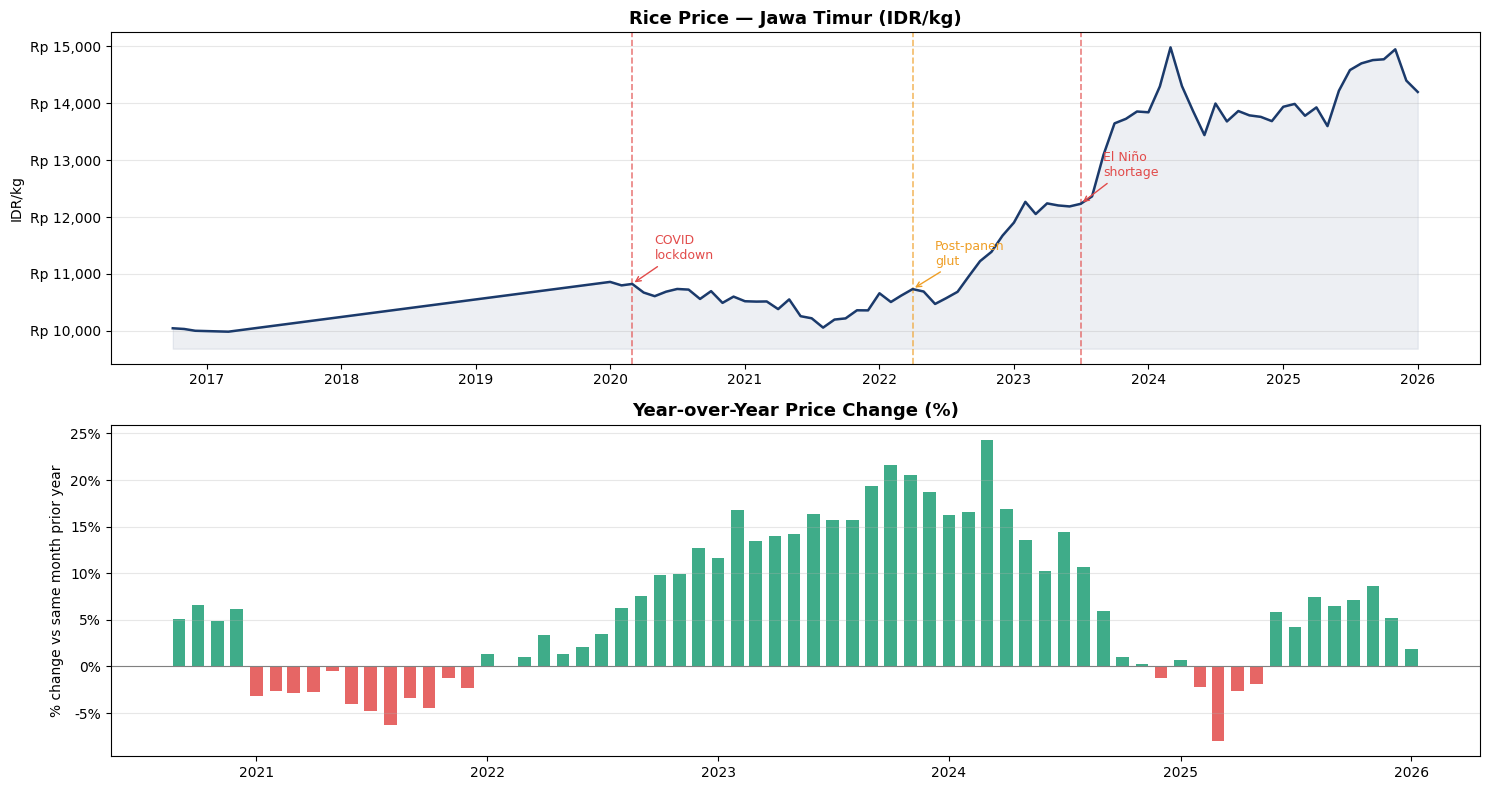

Price statistics:
  Mean:    Rp 12,050
  Median:  Rp 11,389
  Std:     Rp 1,687
  Min:     Rp 9,985  (2017-03-01)
  Max:     Rp 14,984  (2024-03-01)
  Skew:    0.344  (>1 = right-skewed, needs multiplicative seasonality)


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
 
# ── Panel 1: Full price series with annotations ───────────────────────────
ax = axes[0]
ax.plot(master["ds"], master["y"], color="#1B3A6B", linewidth=1.8, zorder=3)
ax.fill_between(master["ds"], master["y"],
                master["y"].min() * 0.97,
                alpha=0.08, color="#1B3A6B")
 
# Annotate known events
events = [
    ("2020-03", "COVID\nlockdown",  "#E24B4A"),
    ("2022-04", "Post-panen\nglut", "#EF9F27"),
    ("2023-07", "El Niño\nshortage","#E24B4A"),
]
for date_str, label, color in events:
    ts = pd.Timestamp(date_str)
    if master["ds"].min() <= ts <= master["ds"].max():
        ax.axvline(ts, color=color, linestyle="--", linewidth=1.2, alpha=0.7)
        price_at = master[master["ds"] >= ts]["y"].iloc[0] if len(master[master["ds"] >= ts]) > 0 else master["y"].mean()
        ax.annotate(label, xy=(ts, price_at),
                    xytext=(ts + pd.DateOffset(months=2), price_at * 1.04),
                    fontsize=9, color=color,
                    arrowprops=dict(arrowstyle="->", color=color, lw=1))
 
ax.set_title("Rice Price — Jawa Timur (IDR/kg)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp {x:,.0f}"))
ax.set_ylabel("IDR/kg")
ax.grid(axis="y", alpha=0.3)
 
# ── Panel 2: Year-over-year % change ─────────────────────────────────────
ax2 = axes[1]
yoy = master.set_index("ds")["y"].pct_change(12) * 100
colors_yoy = ["#1D9E75" if v >= 0 else "#E24B4A" for v in yoy.fillna(0)]
ax2.bar(master["ds"], yoy, color=colors_yoy, width=20, alpha=0.85)
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.set_title("Year-over-Year Price Change (%)", fontsize=13, fontweight="bold")
ax2.set_ylabel("% change vs same month prior year")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.grid(axis="y", alpha=0.3)
 
plt.tight_layout()
plt.savefig("../data/processed/eda_01_price_overview.png", dpi=130, bbox_inches="tight")
plt.show()
 
# Print key stats
print("Price statistics:")
print(f"  Mean:    Rp {master['y'].mean():,.0f}")
print(f"  Median:  Rp {master['y'].median():,.0f}")
print(f"  Std:     Rp {master['y'].std():,.0f}")
print(f"  Min:     Rp {master['y'].min():,.0f}  ({master.loc[master['y'].idxmin(), 'ds'].date()})")
print(f"  Max:     Rp {master['y'].max():,.0f}  ({master.loc[master['y'].idxmax(), 'ds'].date()})")
print(f"  Skew:    {master['y'].skew():.3f}  (>1 = right-skewed, needs multiplicative seasonality)")

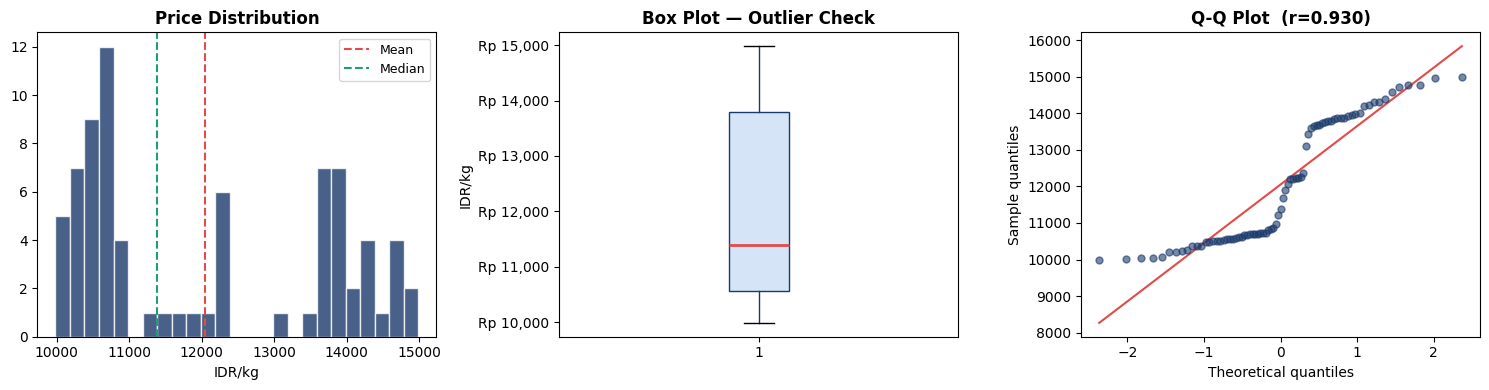

IQR fence: Rp 5,718 – Rp 18,632
Outlier rows flagged: 0


In [31]:
# CELL 26: EDA — PRICE DISTRIBUTION & OUTLIER CHECK
# Goal: decide if outliers need treatment. Prophet handles them, but extreme
# outliers should be documented so judges understand the model's behavior.
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# ── Histogram ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(master["y"], bins=25, color="#1B3A6B", alpha=0.8, edgecolor="white")
ax.axvline(master["y"].mean(),   color="#E24B4A", linestyle="--", linewidth=1.5, label="Mean")
ax.axvline(master["y"].median(), color="#1D9E75", linestyle="--", linewidth=1.5, label="Median")
ax.set_title("Price Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("IDR/kg")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax.legend(fontsize=9)
 
# ── Box plot ──────────────────────────────────────────────────────────────
ax2 = axes[1]
bp = ax2.boxplot(master["y"], vert=True, patch_artist=True,
                 boxprops=dict(facecolor="#D6E4F7", color="#1B3A6B"),
                 medianprops=dict(color="#E24B4A", linewidth=2),
                 whiskerprops=dict(color="#1B3A6B"),
                 flierprops=dict(marker="o", markerfacecolor="#EF9F27",
                                 markersize=7, alpha=0.7))
ax2.set_title("Box Plot — Outlier Check", fontsize=12, fontweight="bold")
ax2.set_ylabel("IDR/kg")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp {x:,.0f}"))
 
# ── Q-Q plot ──────────────────────────────────────────────────────────────
ax3 = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(master["y"], dist="norm")
ax3.scatter(osm, osr, color="#1B3A6B", alpha=0.6, s=25, zorder=3)
line_x = np.array([min(osm), max(osm)])
ax3.plot(line_x, slope * line_x + intercept, color="#E24B4A", linewidth=1.5)
ax3.set_title(f"Q-Q Plot  (r={r:.3f})", fontsize=12, fontweight="bold")
ax3.set_xlabel("Theoretical quantiles")
ax3.set_ylabel("Sample quantiles")
 
plt.tight_layout()
plt.savefig("../data/processed/eda_02_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
 
# IQR-based outlier flag (informational only — do NOT remove, just note)
Q1, Q3 = master["y"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = master[(master["y"] < lower_fence) | (master["y"] > upper_fence)]
 
print(f"IQR fence: Rp {lower_fence:,.0f} – Rp {upper_fence:,.0f}")
print(f"Outlier rows flagged: {len(outliers)}")
if len(outliers) > 0:
    print(outliers[["ds", "y"]].to_string(index=False))
    print("\nNOTE: Do NOT remove these. Prophet treats them as changepoints.")
    print("      Document in model_card.md under 'known anomalies'.")

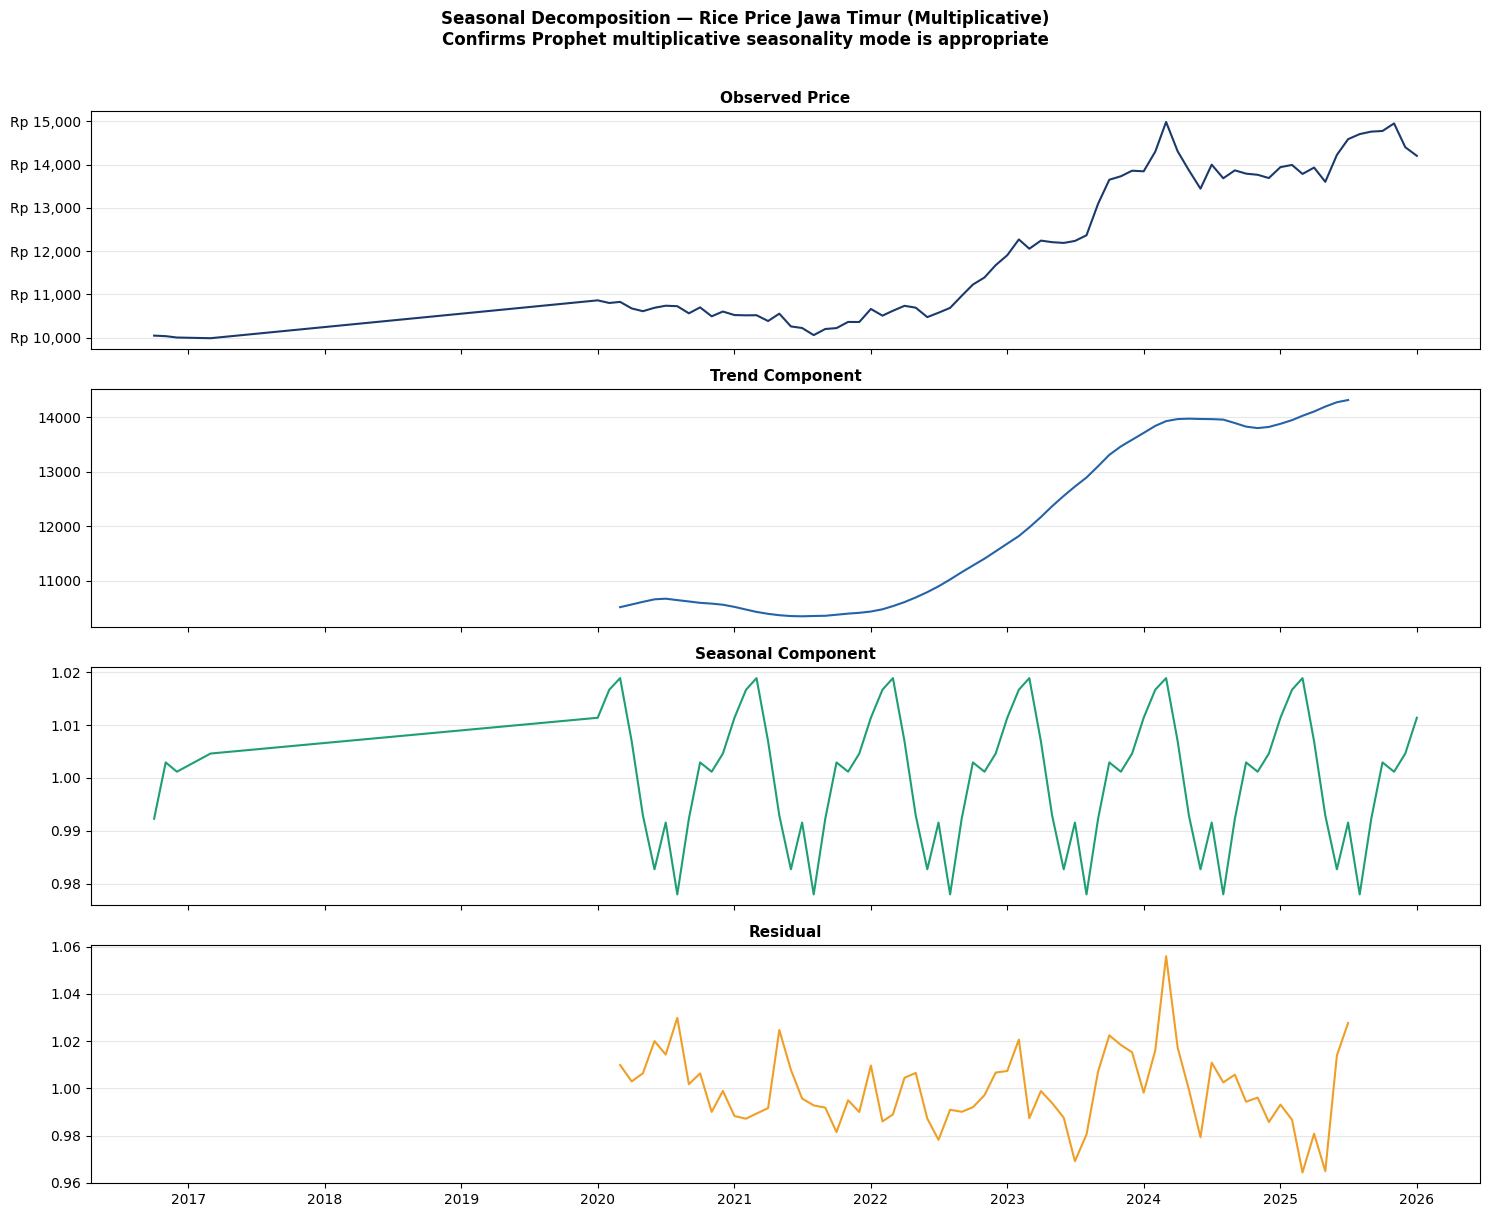

Seasonal range (multiplicative factor): 0.978 – 1.019
Seasonal swing magnitude: 4.1%
Trend range: Rp 3,962

Conclusion: Weak seasonality detected
→ Prophet yearly_seasonality=True is justified


In [32]:
# EDA — SEASONALITY DECOMPOSITION
# Goal: visually confirm that rice price has strong yearly seasonality.
# This is the key justification for choosing Prophet over ARIMA.
# If seasonality is clear → multiplicative mode is correct.
 
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
 
# Use training data only for decomposition
ts = train.set_index("ds")["y"]
 
# Require at least 2 full cycles (24 months) for decomposition
if len(ts) >= 24:
    decomp = seasonal_decompose(ts, model="multiplicative", period=12)
 
    components = [
        (ts,                "Observed Price",    "#1B3A6B"),
        (decomp.trend,      "Trend Component",   "#2563A8"),
        (decomp.seasonal,   "Seasonal Component","#1D9E75"),
        (decomp.resid,      "Residual",          "#EF9F27"),
    ]
    for i, (series, title, color) in enumerate(components):
        axes[i].plot(series.index, series.values, color=color, linewidth=1.5)
        axes[i].set_title(title, fontsize=11, fontweight="bold")
        axes[i].grid(axis="y", alpha=0.3)
        if i == 0:
            axes[i].yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, _: f"Rp {x:,.0f}")
            )
 
    plt.suptitle(
        "Seasonal Decomposition — Rice Price Jawa Timur (Multiplicative)\n"
        "Confirms Prophet multiplicative seasonality mode is appropriate",
        fontsize=12, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.savefig("../data/processed/eda_03_decomposition.png", dpi=130, bbox_inches="tight")
    plt.show()
 
    # Seasonality strength: ratio of seasonal range to overall range
    seasonal_range = decomp.seasonal.max() - decomp.seasonal.min()
    trend_range    = decomp.trend.dropna().max() - decomp.trend.dropna().min()
    print(f"Seasonal range (multiplicative factor): {decomp.seasonal.min():.3f} – {decomp.seasonal.max():.3f}")
    print(f"Seasonal swing magnitude: {(seasonal_range / decomp.seasonal.mean()) * 100:.1f}%")
    print(f"Trend range: Rp {trend_range:,.0f}")
    print(f"\nConclusion: {'Strong' if seasonal_range > 0.1 else 'Weak'} seasonality detected")
    print("→ Prophet yearly_seasonality=True is justified")
else:
    print(f"WARNING: Only {len(ts)} rows in training — need ≥24 for decomposition")
    print("Skipping decomposition. Check WFP data coverage.")

In [33]:
# CELL 28: EDA — STATIONARITY TEST (ADF)
# Goal: document whether the price series is stationary.
# Prophet handles non-stationary series natively — this is for documentation.
 
print("=" * 55)
print("Augmented Dickey-Fuller Test — Price Series (y)")
print("=" * 55)
print("H0: series has a unit root (non-stationary)")
print("H1: series is stationary")
print()
 
adf_result = adfuller(train["y"].dropna(), autolag="AIC")
 
adf_stat  = adf_result[0]
p_value   = adf_result[1]
n_lags    = adf_result[2]
crit_vals = adf_result[4]
 
print(f"ADF statistic:   {adf_stat:.4f}")
print(f"p-value:         {p_value:.4f}")
print(f"Lags used:       {n_lags}")
print(f"Critical values:")
for key, val in crit_vals.items():
    sig = " ← ADF stat is below this" if adf_stat < val else ""
    print(f"  {key}: {val:.4f}{sig}")
 
print()
if p_value < 0.05:
    print("RESULT: Reject H0 → Series is STATIONARY (p < 0.05)")
    print("→ Prophet can model this directly without differencing")
else:
    print("RESULT: Fail to reject H0 → Series is NON-STATIONARY (p ≥ 0.05)")
    print("→ Series has a trend component — this is EXPECTED for rice prices")
    print("→ Prophet's trend component handles this automatically")
    print("→ No action needed — document in model_card.md")

Augmented Dickey-Fuller Test — Price Series (y)
H0: series has a unit root (non-stationary)
H1: series is stationary

ADF statistic:   -0.6262
p-value:         0.8649
Lags used:       0
Critical values:
  1%: -3.5195
  5%: -2.9004
  10%: -2.5875

RESULT: Fail to reject H0 → Series is NON-STATIONARY (p ≥ 0.05)
→ Series has a trend component — this is EXPECTED for rice prices
→ Prophet's trend component handles this automatically
→ No action needed — document in model_card.md


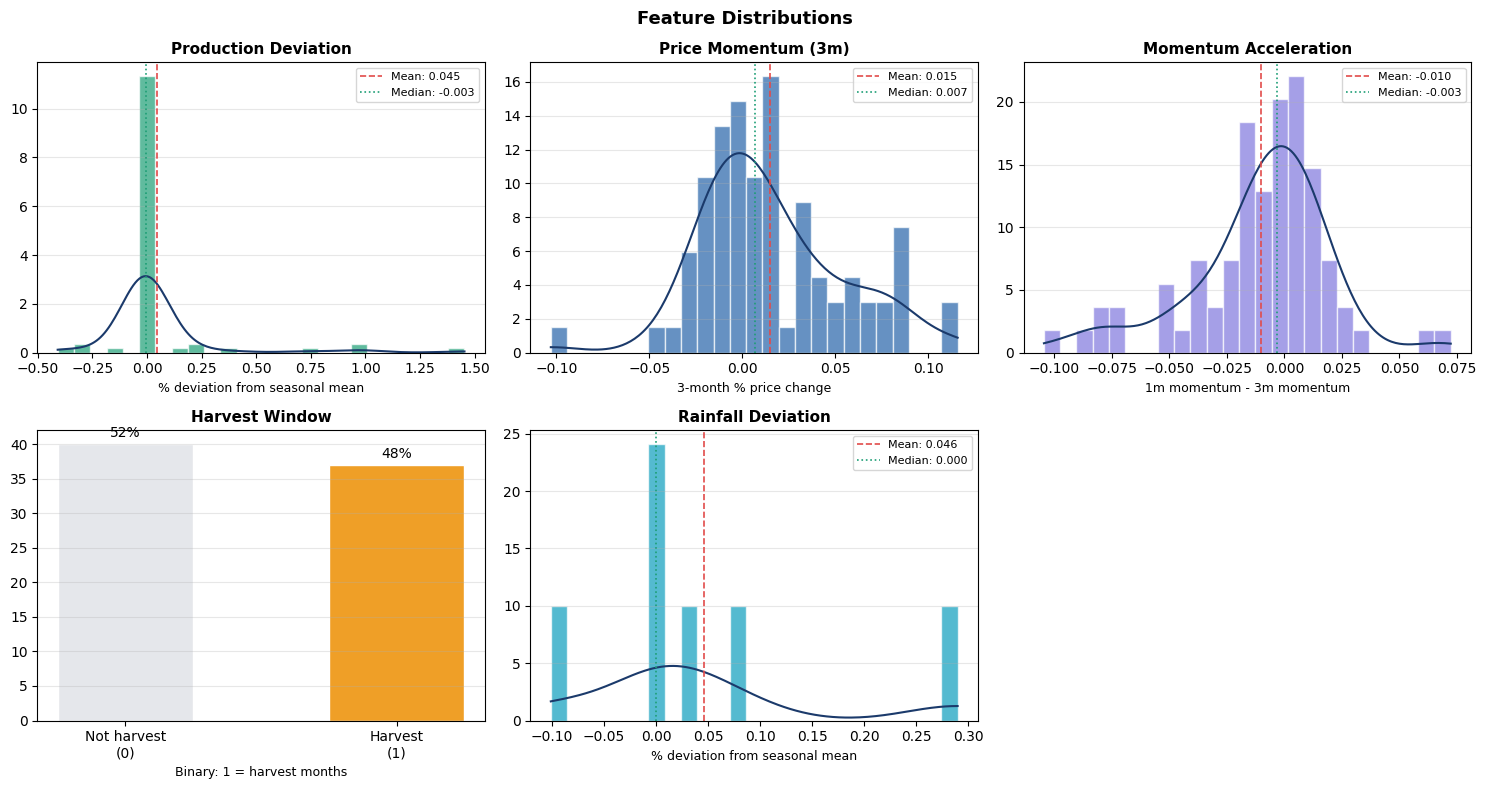

Feature variance check (std > 0.01 = useful):
  production_dev_pct        std=0.2577  ✓
  price_mom_3m              std=0.0386  ✓
  price_accel               std=0.0304  ✓
  harvest_window            std=0.5029  ✓
  rainfall_dev_pct          std=0.1174  ✓


In [34]:
# EDA — FEATURE DISTRIBUTIONS
# Goal: inspect each feature's distribution. Spot if any are heavily skewed
# or near-constant (which would make them useless as regressors).
 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
 
feature_meta = {
    "production_dev_pct": ("Production Deviation",  "#1D9E75", "% deviation from seasonal mean"),
    "price_mom_3m":       ("Price Momentum (3m)",   "#2563A8", "3-month % price change"),
    "price_accel":        ("Momentum Acceleration", "#7F77DD", "1m momentum - 3m momentum"),
    "harvest_window":     ("Harvest Window",        "#EF9F27", "Binary: 1 = harvest months"),
    "rainfall_dev_pct":   ("Rainfall Deviation",    "#0C9DBD", "% deviation from seasonal mean"),
}
 
for i, (col, (title, color, xlabel)) in enumerate(feature_meta.items()):
    ax = axes[i]
    data = master[col].dropna()
 
    if master[col].nunique() <= 2:
        # Binary: bar chart
        counts = master[col].value_counts()
        ax.bar(["Not harvest\n(0)", "Harvest\n(1)"],
               [counts.get(0, 0), counts.get(1, 0)],
               color=["#E5E7EB", color], edgecolor="white", width=0.5)
        ax.set_title(title, fontsize=11, fontweight="bold")
        total = len(master[col])
        for j, (val, cnt) in enumerate([(0, counts.get(0, 0)), (1, counts.get(1, 0))]):
            ax.text(j, cnt + 1, f"{cnt/total*100:.0f}%", ha="center", fontsize=10)
    else:
        # Continuous: histogram + KDE
        ax.hist(data, bins=25, color=color, alpha=0.7, edgecolor="white", density=True)
        kde_x = np.linspace(data.min(), data.max(), 200)
        kde = stats.gaussian_kde(data.dropna())
        ax.plot(kde_x, kde(kde_x), color="#1B3A6B", linewidth=1.5)
        ax.axvline(data.mean(),   color="#E24B4A", linestyle="--", linewidth=1.2, label=f"Mean: {data.mean():.3f}")
        ax.axvline(data.median(), color="#1D9E75", linestyle=":", linewidth=1.2,  label=f"Median: {data.median():.3f}")
        ax.legend(fontsize=8)
        ax.set_title(title, fontsize=11, fontweight="bold")
 
    ax.set_xlabel(xlabel, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
 
# Hide unused subplot
axes[-1].set_visible(False)
 
plt.suptitle("Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/eda_04_feature_distributions.png", dpi=130, bbox_inches="tight")
plt.show()
 
# Variance check — near-constant features are useless as regressors
print("Feature variance check (std > 0.01 = useful):")
for col in FEATURE_COLS:
    std = master[col].std()
    status = "✓" if std > 0.01 else "⚠ NEAR-CONSTANT — consider dropping"
    print(f"  {col:<25} std={std:.4f}  {status}")

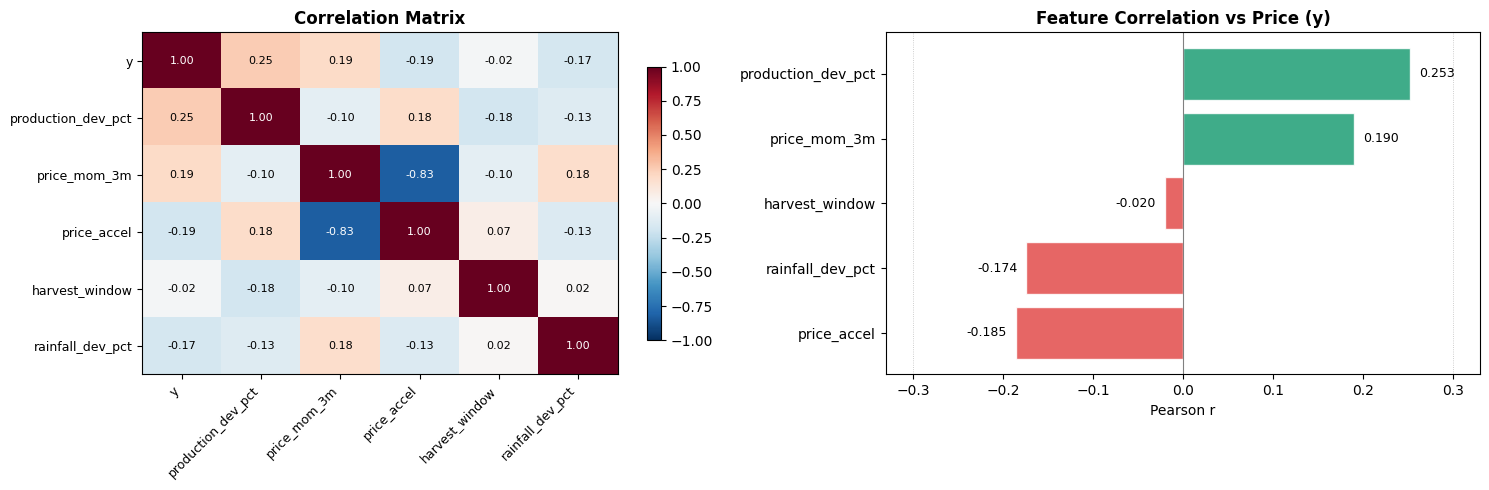

Correlation with price (y):
  production_dev_pct        r=+0.253  → weak signal
  price_mom_3m              r=+0.190  → weak signal
  price_accel               r=-0.185  → weak signal
  harvest_window            r=-0.020  → ⚠ near-zero — may not help Prophet
  rainfall_dev_pct          r=-0.174  → weak signal

Inter-feature correlation (|r| > 0.7 = potential problem):
  ⚠ price_mom_3m vs price_accel: r=-0.826 — consider dropping one


In [35]:
# EDA — CORRELATION MATRIX
# Goal: confirm features have signal vs y (the price).
# Also check inter-feature correlation — highly correlated features
# can cause instability in Prophet's regressor coefficients.
 
corr_cols = ["y"] + FEATURE_COLS
corr_matrix = master[corr_cols].corr()
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(val) > 0.5 else "black")
ax.set_title("Correlation Matrix", fontsize=12, fontweight="bold")
 
# ── Bar chart: correlation of each feature vs y ───────────────────────────
ax2 = axes[1]
feature_corrs = corr_matrix["y"].drop("y").sort_values()
colors_bar = ["#1D9E75" if v > 0 else "#E24B4A" for v in feature_corrs]
bars = ax2.barh(feature_corrs.index, feature_corrs.values,
                color=colors_bar, alpha=0.85, edgecolor="white")
ax2.axvline(0, color="gray", linewidth=0.8)
ax2.axvline( 0.3, color="gray", linewidth=0.6, linestyle=":", alpha=0.5)
ax2.axvline(-0.3, color="gray", linewidth=0.6, linestyle=":", alpha=0.5)
ax2.set_title("Feature Correlation vs Price (y)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Pearson r")
for bar, val in zip(bars, feature_corrs.values):
    ax2.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
 
plt.tight_layout()
plt.savefig("../data/processed/eda_05_correlation.png", dpi=130, bbox_inches="tight")
plt.show()
 
# Interpretation guide
print("Correlation with price (y):")
for feat in FEATURE_COLS:
    r = corr_matrix.loc["y", feat]
    if abs(r) >= 0.3:
        strength = "moderate-strong signal"
    elif abs(r) >= 0.1:
        strength = "weak signal"
    else:
        strength = "⚠ near-zero — may not help Prophet"
    print(f"  {feat:<25} r={r:+.3f}  → {strength}")
 
# Multi-collinearity check
print("\nInter-feature correlation (|r| > 0.7 = potential problem):")
problem_found = False
for i, f1 in enumerate(FEATURE_COLS):
    for f2 in FEATURE_COLS[i+1:]:
        r = corr_matrix.loc[f1, f2]
        if abs(r) > 0.7:
            print(f"  ⚠ {f1} vs {f2}: r={r:.3f} — consider dropping one")
            problem_found = True
if not problem_found:
    print("  ✓ No severe multi-collinearity detected")

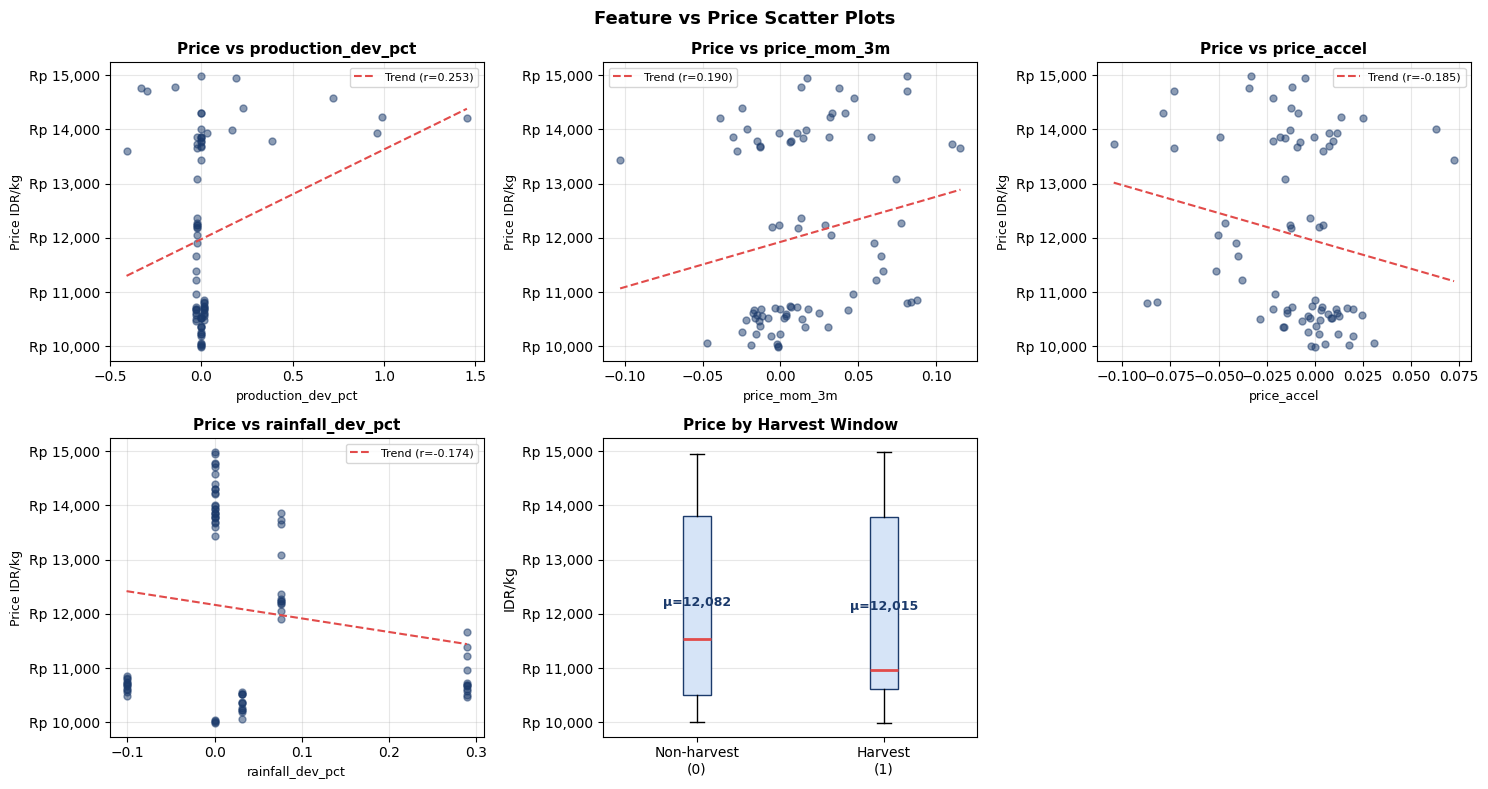

In [36]:
# EDA — FEATURE vs PRICE SCATTER PLOTS
# Goal: visualize the relationship between each feature and price visually.
# Confirms correlation findings and spots non-linear relationships.
 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
 
continuous_features = [f for f in FEATURE_COLS if master[f].nunique() > 2]
 
for i, col in enumerate(continuous_features):
    ax = axes[i]
    x = master[col].values
    y = master["y"].values
 
    # Scatter
    ax.scatter(x, y, alpha=0.5, s=25, color="#1B3A6B", zorder=2)
 
    # Trend line
    valid = ~(np.isnan(x) | np.isnan(y))
    if valid.sum() > 3:
        z = np.polyfit(x[valid], y[valid], 1)
        p = np.poly1d(z)
        x_line = np.linspace(x[valid].min(), x[valid].max(), 100)
        ax.plot(x_line, p(x_line), color="#E24B4A", linewidth=1.5,
                linestyle="--", label=f"Trend (r={np.corrcoef(x[valid],y[valid])[0,1]:.3f})")
    ax.legend(fontsize=8)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("Price IDR/kg", fontsize=9)
    ax.set_title(f"Price vs {col}", fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"Rp {v:,.0f}"))
    ax.grid(alpha=0.3)
 
# Box plot: price by harvest window
ax_box = axes[len(continuous_features)]
groups = [master[master["harvest_window"] == 0]["y"].values,
          master[master["harvest_window"] == 1]["y"].values]
bp = ax_box.boxplot(groups, patch_artist=True, labels=["Non-harvest\n(0)", "Harvest\n(1)"],
                    boxprops=dict(facecolor="#D6E4F7", color="#1B3A6B"),
                    medianprops=dict(color="#E24B4A", linewidth=2))
ax_box.set_title("Price by Harvest Window", fontsize=11, fontweight="bold")
ax_box.set_ylabel("IDR/kg")
ax_box.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"Rp {v:,.0f}"))
ax_box.grid(axis="y", alpha=0.3)
 
# Add mean labels
for j, grp in enumerate(groups):
    ax_box.text(j + 1, np.mean(grp), f"μ={np.mean(grp):,.0f}",
                ha="center", va="bottom", fontsize=9, color="#1B3A6B", fontweight="bold")
 
# Hide last unused subplot if any
if len(continuous_features) + 1 < len(axes):
    axes[-1].set_visible(False)
 
plt.suptitle("Feature vs Price Scatter Plots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/eda_06_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

Feature completeness by year:
(production_dev_pct rows filled with 0 in 2024 = gap fill, expected)

      rows  price_mean  prod_dev_mean  prod_dev_std  rain_dev_mean
year                                                              
2016     3   10026.039         -0.003         0.000          0.000
2017     1    9984.917         -0.003           NaN          0.000
2020    12   10688.918          0.015         0.000         -0.101
2021    12   10346.419         -0.001         0.000          0.032
2022    12   10849.647         -0.028         0.000          0.290
2023    12   12648.439         -0.021         0.000          0.077
2024    12   13959.919         -0.003         0.000          0.000
2025    12   14303.145          0.208         0.482          0.000
2026     1   14200.000          1.454           NaN          0.000

⚠ Flag: if prod_dev_std is 0.0 for any year → that year is entirely gap-filled
   This means the production signal for that year is artificial.
   Acceptable for 

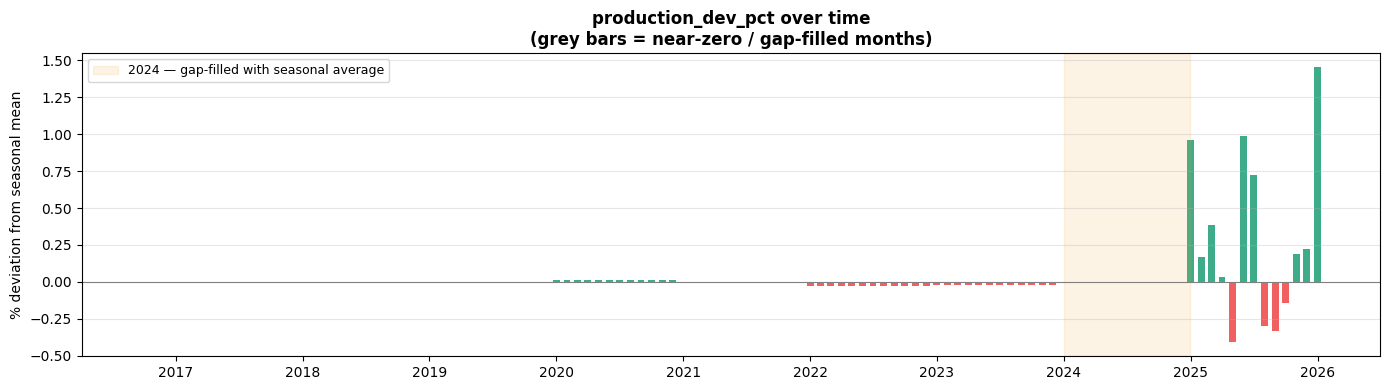

In [37]:
# CELL 32: EDA — FEATURE COMPLETENESS BY YEAR
# Goal: verify the 2024 gap fill didn't create flat/unnatural patterns.
# Check how much of each feature is real data vs filled.
 
print("Feature completeness by year:")
print("(production_dev_pct rows filled with 0 in 2024 = gap fill, expected)\n")
 
master["year"] = master["ds"].dt.year
summary = master.groupby("year").agg(
    rows=("y", "count"),
    price_mean=("y", "mean"),
    prod_dev_mean=("production_dev_pct", "mean"),
    prod_dev_std=("production_dev_pct", "std"),
    rain_dev_mean=("rainfall_dev_pct", "mean"),
).round(3)
print(summary.to_string())
master.drop(columns=["year"], inplace=True)
 
print("\n⚠ Flag: if prod_dev_std is 0.0 for any year → that year is entirely gap-filled")
print("   This means the production signal for that year is artificial.")
print("   Acceptable for ≤12 months. Document in model_card.md.\n")
 
# Plot production_dev_pct over time, highlight gap-filled region
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(master["ds"], master["production_dev_pct"],
       width=20,
       color=["#1D9E75" if v > 0.001 else "#EF4444" if v < -0.001 else "#D1D5DB"
              for v in master["production_dev_pct"]],
       alpha=0.85)
ax.axhline(0, color="gray", linewidth=0.8)
 
# Shade 2024 gap region
ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"),
           alpha=0.12, color="#EF9F27",
           label="2024 — gap-filled with seasonal average")
 
ax.set_title("production_dev_pct over time\n(grey bars = near-zero / gap-filled months)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("% deviation from seasonal mean")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/eda_07_production_completeness.png", dpi=130, bbox_inches="tight")
plt.show()

In [38]:
# EDA — SUMMARY REPORT
# Final checklist before moving to model training.
# Every item should be ✓. If any are ⚠, read the note and decide.
 
print("=" * 60)
print("EDA SUMMARY REPORT — Pre-model checklist")
print("=" * 60)
 
checks = []
 
# 1. Sufficient training rows
n_train = len(train)
checks.append((
    n_train >= 60,
    f"Training rows ≥60",
    f"{n_train} rows",
    "Prophet needs at least 2 full seasonal cycles"
))
 
# 2. Price range sanity
avg_price = master["y"].mean()
checks.append((
    5000 < avg_price < 30000,
    "Price range sane (5,000–30,000 IDR/kg)",
    f"Rp {avg_price:,.0f}/kg",
    "Check if price column parsed correctly"
))
 
# 3. Seasonality exists
if "decomp" in dir() and hasattr(decomp, "seasonal"):
    seasonal_strength = decomp.seasonal.max() - decomp.seasonal.min()
    checks.append((
        seasonal_strength > 0.05,
        "Seasonality detected (multiplicative factor range > 0.05)",
        f"range = {seasonal_strength:.3f}",
        "If weak, change seasonality_mode to additive"
    ))
 
# 4. No constant features
for col in FEATURE_COLS:
    std = master[col].std()
    checks.append((
        std > 0.01,
        f"Feature '{col}' has variance (std > 0.01)",
        f"std = {std:.4f}",
        "Near-constant features add noise, not signal — consider dropping"
    ))
 
# 5. No nulls in key columns
null_count = master[["y"] + FEATURE_COLS].isna().sum().sum()
checks.append((
    null_count == 0,
    "No null values in y or features",
    f"{null_count} nulls",
    "Fix null filling in Cell 20 before proceeding"
))
 
# 6. ADF test documented
checks.append((
    True,
    "ADF stationarity test run (Cell 28)",
    f"p-value = {p_value:.4f}",
    "Non-stationarity is fine — Prophet handles trends natively"
))
 
# 7. Features have some signal
sig_features = sum(1 for f in FEATURE_COLS if abs(corr_matrix.loc["y", f]) >= 0.1)
checks.append((
    sig_features >= 2,
    f"At least 2 features with |r| ≥ 0.1 vs price",
    f"{sig_features} of {len(FEATURE_COLS)} features",
    "If fewer, model is weak — review feature engineering"
))
 
# Print results
all_pass = True
for passed, label, value, note in checks:
    icon = "✓" if passed else "⚠"
    print(f"  {icon}  {label}")
    print(f"       Value: {value}")
    if not passed:
        print(f"       Note:  {note}")
        all_pass = False
    print()
 
print("=" * 60)
if all_pass:
    print("✓ ALL CHECKS PASSED — Ready for model training (02_MODEL)")
else:
    print("⚠ Some checks failed — review notes above before proceeding")
print("=" * 60)
 
print("\nEDA plots saved to data/processed/:")
for i, name in enumerate([
    "eda_01_price_overview.png",
    "eda_02_distribution.png",
    "eda_03_decomposition.png",
    "eda_04_feature_distributions.png",
    "eda_05_correlation.png",
    "eda_06_scatter.png",
    "eda_07_production_completeness.png",
], 1):
    print(f"  {i}. {name}")

EDA SUMMARY REPORT — Pre-model checklist
  ✓  Training rows ≥60
       Value: 77 rows

  ✓  Price range sane (5,000–30,000 IDR/kg)
       Value: Rp 12,050/kg

  ⚠  Seasonality detected (multiplicative factor range > 0.05)
       Value: range = 0.041
       Note:  If weak, change seasonality_mode to additive

  ✓  Feature 'production_dev_pct' has variance (std > 0.01)
       Value: std = 0.2577

  ✓  Feature 'price_mom_3m' has variance (std > 0.01)
       Value: std = 0.0386

  ✓  Feature 'price_accel' has variance (std > 0.01)
       Value: std = 0.0304

  ✓  Feature 'harvest_window' has variance (std > 0.01)
       Value: std = 0.5029

  ✓  Feature 'rainfall_dev_pct' has variance (std > 0.01)
       Value: std = 0.1174

  ✓  No null values in y or features
       Value: 0 nulls

  ✓  ADF stationarity test run (Cell 28)
       Value: p-value = 0.8649

  ✓  At least 2 features with |r| ≥ 0.1 vs price
       Value: 4 of 5 features

⚠ Some checks failed — review notes above before proceed